In [14]:
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv('car_sales_data.csv')

In [16]:
print(df.shape)        # how many rows and columns
print(df.head())       # first 5 rows
print(df.info())       # column types and nulls
print(df.describe())   # stats for numbers

(50000, 7)
  Manufacturer       Model  Engine size Fuel type  Year of manufacture  \
0         Ford      Fiesta          1.0    Petrol                 2002   
1      Porsche  718 Cayman          4.0    Petrol                 2016   
2         Ford      Mondeo          1.6    Diesel                 2014   
3       Toyota        RAV4          1.8    Hybrid                 1988   
4           VW        Polo          1.0    Petrol                 2006   

   Mileage  Price  
0   127300   3074  
1    57850  49704  
2    39190  24072  
3   210814   1705  
4   127869   4101  
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         50000 non-null  str    
 1   Model                50000 non-null  str    
 2   Engine size          50000 non-null  float64
 3   Fuel type            50000 non-null  str    
 4   Year of manufacture  5

In [17]:
print('Missing values:\n', df.isnull().sum())
print('Duplicates:', df.duplicated().sum())


Missing values:
 Manufacturer           0
Model                  0
Engine size            0
Fuel type              0
Year of manufacture    0
Mileage                0
Price                  0
dtype: int64
Duplicates: 12


In [18]:
df = df.drop_duplicates()                  # remove duplicates


In [19]:
print('Duplicates:', df.duplicated().sum())


Duplicates: 0


## Finding: Porsche has the highest average price (~£29,000), while VW is the cheapest (~£10,000)

In [20]:
print(df.groupby('Manufacturer')['Price'].mean().sort_values(ascending=False))

Manufacturer
Porsche    29103.764661
BMW        24431.679089
Toyota     14341.099418
Ford       10671.473455
VW         10361.781497
Name: Price, dtype: float64


## Finding: Higher mileage strongly reduces price (correlation: -0.63)

In [21]:
print(df[['Mileage', 'Price']].corr())

          Mileage     Price
Mileage  1.000000 -0.632817
Price   -0.632817  1.000000


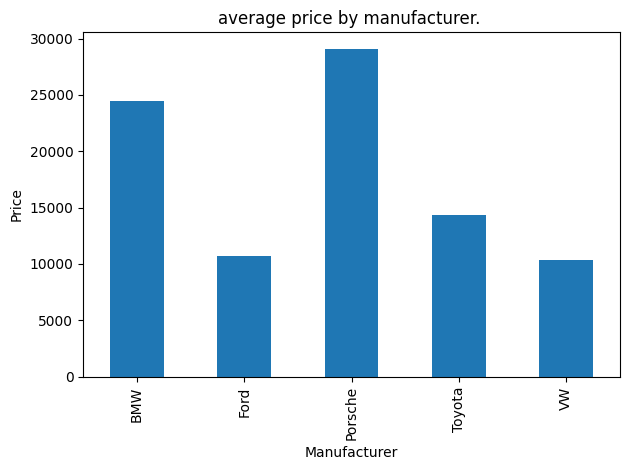

In [22]:
df.groupby('Manufacturer')['Price'].mean().plot(kind='bar')
plt.title('average price by manufacturer. ')
plt.xlabel('Manufacturer')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

In [23]:
print(df.groupby('Manufacturer')['Model'].count().sort_values(ascending=False))


Manufacturer
Ford       14956
VW         14906
Toyota     12553
BMW         4964
Porsche     2609
Name: Model, dtype: int64


## Finding: Ford and VW dominate the market with ~15,000 cars each

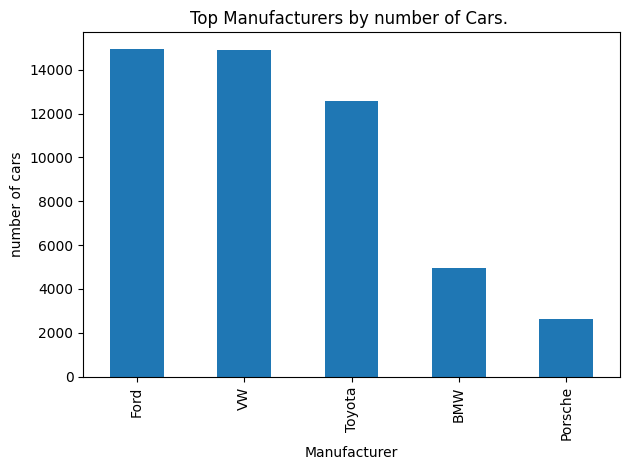

In [24]:
df.groupby('Manufacturer')['Model'].count().sort_values(ascending=False).plot(kind='bar')
plt.title('Top Manufacturers by number of Cars. ')
plt.xlabel('Manufacturer')
plt.ylabel('number of cars')
plt.tight_layout()
plt.show()

## Finding: Hybrid cars are the most expensive fuel type on average

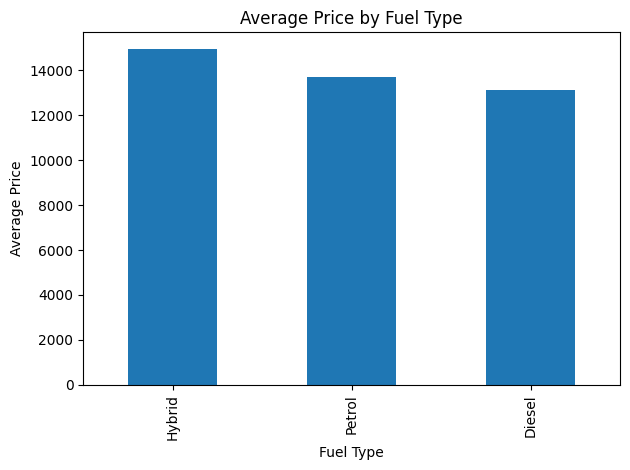

In [25]:
df.groupby('Fuel type')['Price'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Average Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average Price')
plt.tight_layout()
plt.show()

## Finding: Histogram "Most cars are priced under £25,000, with very few exceeding £75,000.

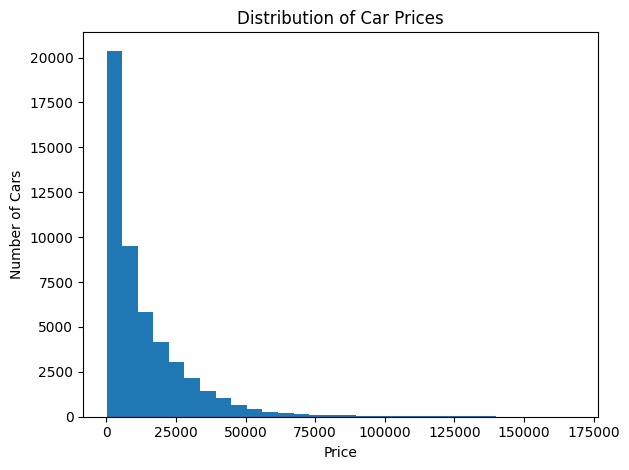

In [38]:
df['Price'].plot(kind='hist', bins=30)
plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Number of Cars')
plt.tight_layout()
plt.show()

## Finding: bar Chart "Porsche has the highest average price at £29,000, nearly 3x more than Ford and VW.

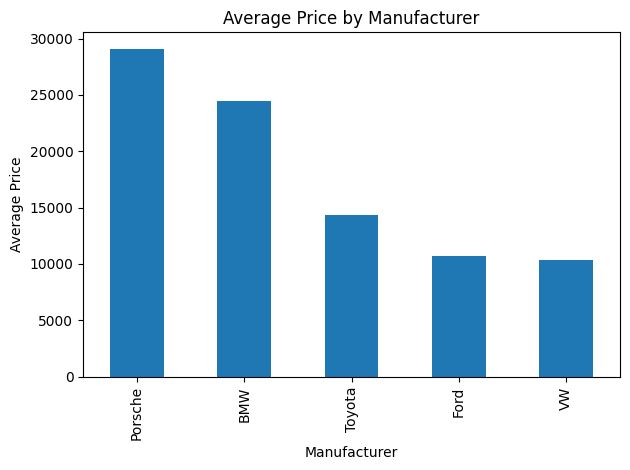

In [48]:
df.groupby('Manufacturer')['Price'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Average Price by Manufacturer')
plt.xlabel('Manufacturer')
plt.ylabel('Average Price')
plt.tight_layout()
plt.show()

## Finding: Box Plot "Porsche shows the widest price variation while Ford and VW are the most consistently priced.

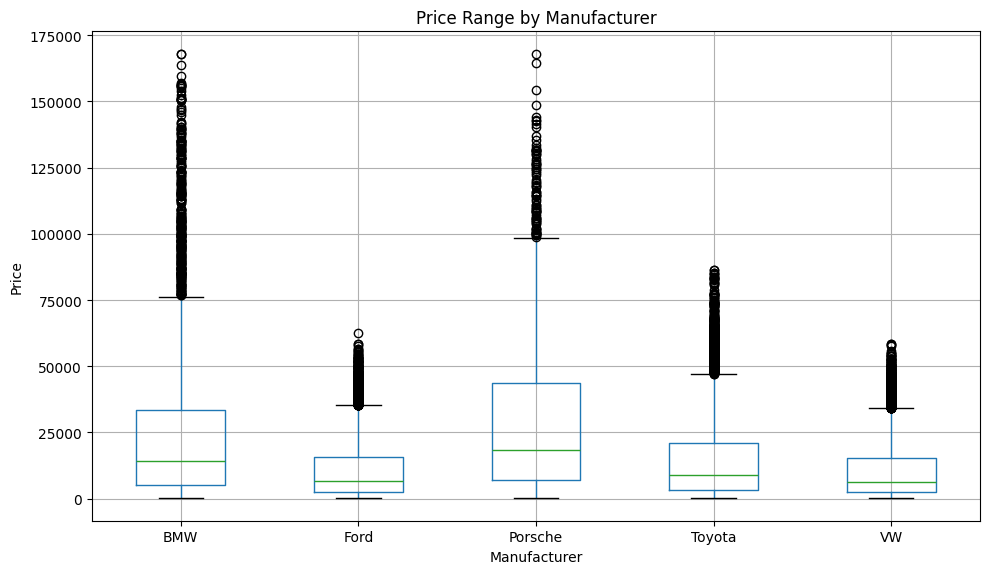

In [49]:
df.boxplot(column='Price', by='Manufacturer', figsize=(10,6))
plt.title('Price Range by Manufacturer')
plt.suptitle('')
plt.xlabel('Manufacturer')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

## Finding: Hybrid cars have the highest average price, followed by Petrol and Diesel.

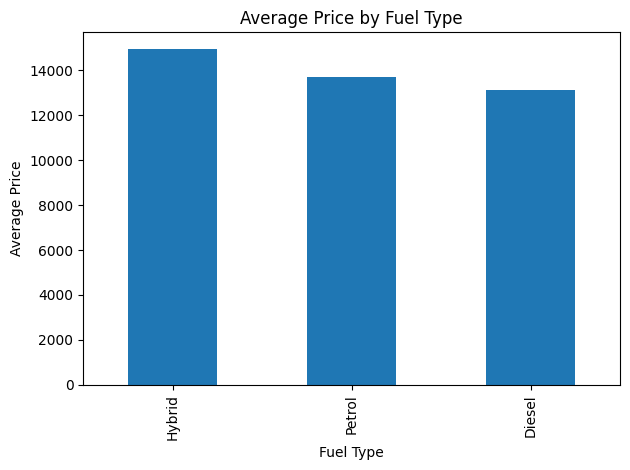

In [50]:
df.groupby('Fuel type')['Price'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Average Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average Price')
plt.tight_layout()
plt.show()

## Finding: Newer cars are significantly more expensive. Prices rise sharply after 2015, with 2022 cars averaging £58,000 compared to £1,000 for 1984 models.

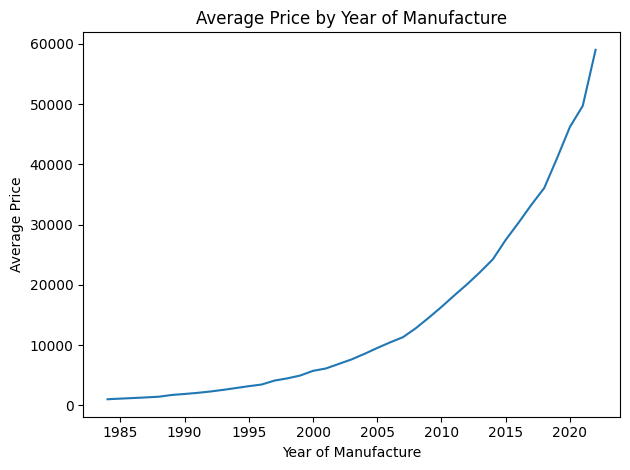

In [53]:
df.groupby('Year of manufacture')['Price'].mean().plot(kind='line')
plt.title('Average Price by Year of Manufacture')
plt.xlabel('Year of Manufacture')
plt.ylabel('Average Price')
plt.tight_layout()
plt.show()